<a href="https://colab.research.google.com/github/WajeehaAslam/Ann_lab/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:

import numpy as np


In [9]:

vocab_size = 10000
max_len = 500


In [10]:
from tensorflow.keras.datasets import imdb
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)



In [11]:

from tensorflow.keras.preprocessing.sequence import pad_sequences
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)


In [12]:
from tensorflow.keras.models import Sequential
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32, input_length=max_len),

    SimpleRNN(32),

    Dense(1, activation='sigmoid')

])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [13]:

from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam

model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])



In [14]:

history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=2
)

Epoch 1/5
313/313 - 44s - 140ms/step - accuracy: 0.6791 - loss: 0.6111 - val_accuracy: 0.8140 - val_loss: 0.4419
Epoch 2/5
313/313 - 82s - 263ms/step - accuracy: 0.8517 - loss: 0.3569 - val_accuracy: 0.8296 - val_loss: 0.4017
Epoch 3/5
313/313 - 79s - 252ms/step - accuracy: 0.8753 - loss: 0.3049 - val_accuracy: 0.8208 - val_loss: 0.4065
Epoch 4/5
313/313 - 43s - 137ms/step - accuracy: 0.7678 - loss: 0.5341 - val_accuracy: 0.7262 - val_loss: 0.5492
Epoch 5/5
313/313 - 41s - 132ms/step - accuracy: 0.9009 - loss: 0.2597 - val_accuracy: 0.7772 - val_loss: 0.5250


In [15]:


loss, accuracy = model.evaluate(x_test, y_test)
print(f'Test Accuracy: {accuracy:.4f}')


782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.7887 - loss: 0.5073
Test Accuracy: 0.7858


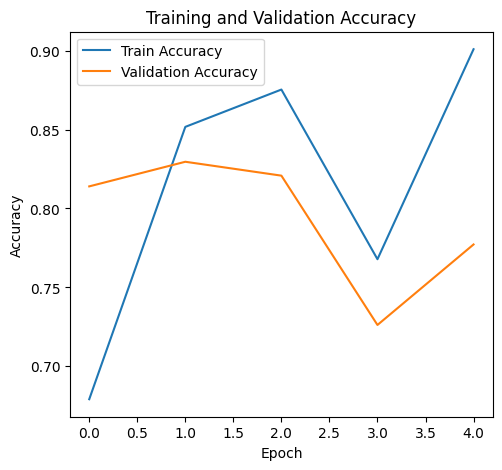

In [16]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

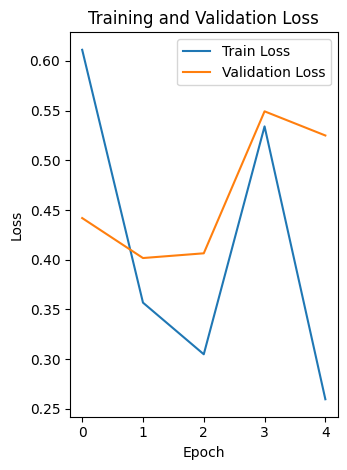

In [17]:



plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [18]:
from pandas import read_csv
import numpy as np
from keras.models import Sequential
from keras.layers import Dense , SimpleRNN
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt


In [19]:
def create_RNN(hidden_units,dense_units,input_shape,activation):
   model=Sequential()
   model.add(SimpleRNN(hidden_units,input_shape=input_shape,activation=activation[0]))
   model.add(Dense(units=dense_units,activation=activation[1]))
   model.compile(loss='mean_squared_error',optimizer='adam')
   return model
demo_model = create_RNN(2,1,(3,1),activation=['linear','linear'])

In [20]:

wx = demo_model.get_weights()[0]
wh = demo_model.get_weights()[1]
bh = demo_model.get_weights()[2]
wy = demo_model.get_weights()[3]
by = demo_model.get_weights()[4]

print('wx = ', wx, ' wh = ', wh, ' bh = ', bh, ' wy =', wy, 'by = ', by)

wx =  [[-0.61598897  0.6785768 ]]  wh =  [[-0.6208458 -0.7839327]
 [ 0.7839327 -0.6208458]]  bh =  [0. 0.]  wy = [[ 1.3566946]
 [-1.093737 ]] by =  [0.]


In [21]:

x = np.array([1, 2, 3])
# Reshape the input to the required sample_size x time_steps x features
x_input = np.reshape(x,(1, 3, 1))
y_pred_model = demo_model.predict(x_input)


m = 2
h0 = np.zeros(m)
h1 = np.dot(x[0], wx) + h0 + bh
h2 = np.dot(x[1], wx) + np.dot(h1,wh) + bh
h3 = np.dot(x[2], wx) + np.dot(h2,wh) + bh
o3 = np.dot(h3, wy) + by

print('h1 = ', h1,'h2 = ', h2,'h3 = ', h3)

print("Prediction from network ", y_pred_model)
print("Prediction from our computation ", o3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
h1 =  [[-0.61598897  0.67857683]] h2 =  [[-0.31758522  1.41875597]] h3 =  [[-0.53858628  1.40386724]]
Prediction from network  [[-2.2661586]]
Prediction from our computation  [[-2.26615864]]


In [22]:
# Parameter split_percent defines the ratio of training examples
def get_train_test(url, split_percent=0.8):
    df = read_csv(url, usecols=[1], engine='python')
    data = np.array(df.values.astype('float32'))
    scaler = MinMaxScaler(feature_range=(0, 1))
    data = scaler.fit_transform(data).flatten()
    n = len(data)
    # Point for splitting data into train and test
    split = int(n*split_percent)
    train_data = data[range(split)]
    test_data = data[split:]
    return train_data, test_data, data

sunspots_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'
train_data, test_data, data = get_train_test(sunspots_url)

In [23]:
# Prepare the input X and target Y
def get_XY(dat, time_steps):
    # Indices of target array
    Y_ind = np.arange(time_steps, len(dat), time_steps)
    Y = dat[Y_ind]
    # Prepare X
    rows_x = len(Y)
    X = dat[range(time_steps*rows_x)]
    X = np.reshape(X, (rows_x, time_steps, 1))
    return X, Y

time_steps = 12
trainX, trainY = get_XY(train_data, time_steps)
testX, testY = get_XY(test_data, time_steps)

In [24]:

model = create_RNN(hidden_units=3, dense_units=1, input_shape=(time_steps,1),
                   activation=['tanh', 'tanh'])
model.fit(trainX, trainY, epochs=20, batch_size=1, verbose=2)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


187/187 - 2s - 10ms/step - loss: 0.0207
Epoch 2/20
187/187 - 1s - 3ms/step - loss: 0.0140
Epoch 3/20
187/187 - 1s - 3ms/step - loss: 0.0114
Epoch 4/20
187/187 - 1s - 3ms/step - loss: 0.0092
Epoch 5/20
187/187 - 1s - 3ms/step - loss: 0.0075
Epoch 6/20
187/187 - 1s - 3ms/step - loss: 0.0065
Epoch 7/20
187/187 - 1s - 3ms/step - loss: 0.0060
Epoch 8/20
187/187 - 1s - 3ms/step - loss: 0.0057
Epoch 9/20
187/187 - 1s - 3ms/step - loss: 0.0057
Epoch 10/20
187/187 - 1s - 5ms/step - loss: 0.0055
Epoch 11/20
187/187 - 1s - 4ms/step - loss: 0.0054
Epoch 12/20
187/187 - 1s - 5ms/step - loss: 0.0053
Epoch 13/20
187/187 - 1s - 5ms/step - loss: 0.0052
Epoch 14/20
187/187 - 1s - 3ms/step - loss: 0.0050
Epoch 15/20
187/187 - 1s - 3ms/step - loss: 0.0050
Epoch 16/20
187/187 - 1s - 3ms/step - loss: 0.0047
Epoch 17/20
187/187 - 1s - 3ms/step - loss: 0.0048
Epoch 18/20
187/187 - 1s - 3ms/step - loss: 0.0048
Epoch 19/20
187/187 - 1s - 3ms/step - loss: 0.0048
Epoch 20/20
187/187 - 0s - 3ms/step - loss: 0.0047

In [25]:

def print_error(trainY, testY, train_predict, test_predict):
    # Error of predictions
    train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))
    test_rmse = math.sqrt(mean_squared_error(testY, test_predict))
    # Print RMSE
    print('Train RMSE: %.3f RMSE' % (train_rmse))
    print('Test RMSE: %.3f RMSE' % (test_rmse))

# make predictions
train_predict = model.predict(trainX)
test_predict = model.predict(testX)
# Mean square error
print_error(trainY, testY, train_predict, test_predict)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Train RMSE: 0.066 RMSE
Test RMSE: 0.098 RMSE


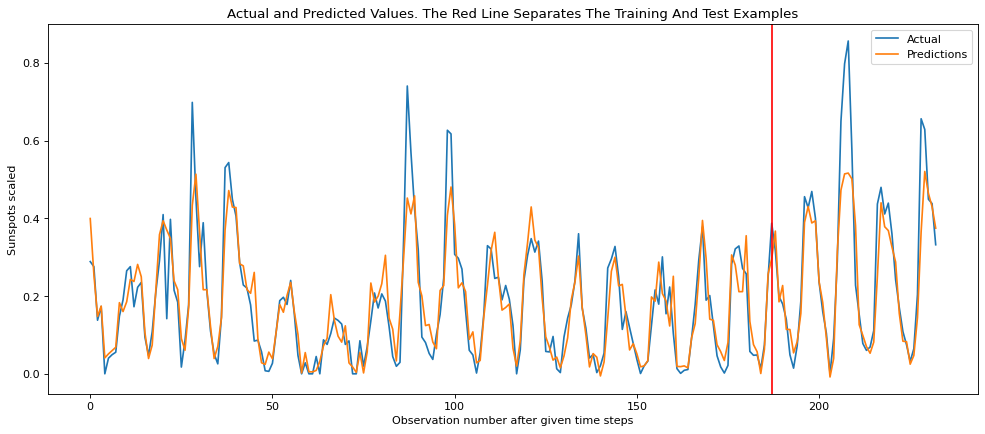

In [26]:

# Plot the result
def plot_result(trainY, testY, train_predict, test_predict):
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)
    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual)
    plt.plot(range(rows), predictions)
    plt.axvline(x=len(trainY), color='r')
    plt.legend(['Actual', 'Predictions'])
    plt.xlabel('Observation number after given time steps')
    plt.ylabel('Sunspots scaled')
    plt.title('Actual and Predicted Values. The Red Line Separates The Training And Test Examples')
plot_result(trainY, testY, train_predict, test_predict)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


187/187 - 2s - 10ms/step - loss: 0.1157
Epoch 2/20
187/187 - 1s - 3ms/step - loss: 0.0336
Epoch 3/20
187/187 - 1s - 3ms/step - loss: 0.0210
Epoch 4/20
187/187 - 1s - 3ms/step - loss: 0.0154
Epoch 5/20
187/187 - 1s - 5ms/step - loss: 0.0123
Epoch 6/20
187/187 - 1s - 4ms/step - loss: 0.0101
Epoch 7/20
187/187 - 1s - 5ms/step - loss: 0.0085
Epoch 8/20
187/187 - 1s - 5ms/step - loss: 0.0072
Epoch 9/20
187/187 - 1s - 3ms/step - loss: 0.0062
Epoch 10/20
187/187 - 1s - 3ms/step - loss: 0.0055
Epoch 11/20
187/187 - 1s - 3ms/step - loss: 0.0049
Epoch 12/20
187/187 - 1s - 3ms/step - loss: 0.0045
Epoch 13/20
187/187 - 1s - 3ms/step - loss: 0.0043
Epoch 14/20
187/187 - 1s - 3ms/step - loss: 0.0041
Epoch 15/20
187/187 - 1s - 3ms/step - loss: 0.0040
Epoch 16/20
187/187 - 1s - 3ms/step - loss: 0.0039
Epoch 17/20
187/187 - 1s - 3ms/step - loss: 0.0038
Epoch 18/20
187/187 - 0s - 3ms/step - loss: 0.0038
Epoch 19/20
187/187 - 1s - 3ms/step - loss: 0.0037
Epoch 20/20
187/187 - 1s - 3ms/step - loss: 0.0036

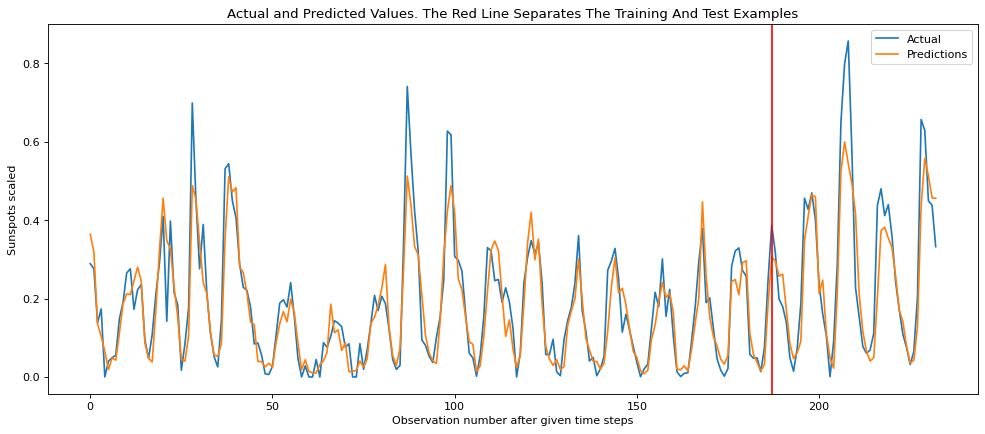

In [27]:
# Parameter split_percent defines the ratio of training examples
def get_train_test(url, split_percent=0.8):
    df = read_csv(url, usecols=[1], engine='python')
    data = np.array(df.values.astype('float32'))
    scaler = MinMaxScaler(feature_range=(0, 1))
    data = scaler.fit_transform(data).flatten()
    n = len(data)
    # Point for splitting data into train and test
    split = int(n*split_percent)
    train_data = data[range(split)]
    test_data = data[split:]
    return train_data, test_data, data

# Prepare the input X and target Y
def get_XY(dat, time_steps):
    Y_ind = np.arange(time_steps, len(dat), time_steps)
    Y = dat[Y_ind]
    rows_x = len(Y)
    X = dat[range(time_steps*rows_x)]
    X = np.reshape(X, (rows_x, time_steps, 1))
    return X, Y

def create_RNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential()
    model.add(SimpleRNN(hidden_units, input_shape=input_shape, activation=activation[0]))
    model.add(Dense(units=dense_units, activation=activation[1]))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

def print_error(trainY, testY, train_predict, test_predict):
    # Error of predictions
    train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))
    test_rmse = math.sqrt(mean_squared_error(testY, test_predict))
    # Print RMSE
    print('Train RMSE: %.3f RMSE' % (train_rmse))
    print('Test RMSE: %.3f RMSE' % (test_rmse))

# Plot the result
def plot_result(trainY, testY, train_predict, test_predict):
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)
    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual)
    plt.plot(range(rows), predictions)
    plt.axvline(x=len(trainY), color='r')
    plt.legend(['Actual', 'Predictions'])
    plt.xlabel('Observation number after given time steps')
    plt.ylabel('Sunspots scaled')
    plt.title('Actual and Predicted Values. The Red Line Separates The Training And Test Examples')

sunspots_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'
time_steps = 12
train_data, test_data, data = get_train_test(sunspots_url)
trainX, trainY = get_XY(train_data, time_steps)
testX, testY = get_XY(test_data, time_steps)

# Create model and train
model = create_RNN(hidden_units=3, dense_units=1, input_shape=(time_steps,1),
                   activation=['tanh', 'tanh'])
model.fit(trainX, trainY, epochs=20, batch_size=1, verbose=2)

# make predictions
train_predict = model.predict(trainX)
test_predict = model.predict(testX)

# Print error
print_error(trainY, testY, train_predict, test_predict)

#Plot result
plot_result(trainY, testY, train_predict, test_predict)